In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv('./defefcts.csv')
dataset

,cbo,wmc,dit,rfc,lcom,totalMethods,totalFields,nosi,loc,returnQty,...,tryCatchQty,parenthesizedExpsQty,stringLiteralsQty,numbersQty,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocks,uniqueWordsQty,defect
0,5,60,2,55,189,27,5,30,247,25,...,4,2,47,9,27,5,17,3,191,0
1,3,10,1,1,9,7,4,1,38,7,...,0,0,0,22,4,0,4,2,69,0
2,3,10,1,1,9,7,4,0,38,7,...,0,0,0,22,4,0,4,2,69,1
3,20,59,3,63,189,24,9,4,262,12,...,0,6,6,14,45,8,41,4,222,0
4,21,58,2,61,189,24,9,0,260,12,...,0,6,6,14,45,8,41,4,222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6047,52,124,12,144,963,110,9,0,804,20,...,0,0,26,16,32,4,30,6,689,1
6048,24,27,2,46,4,8,8,0,126,3,...,0,1,3,14,27,0,24,3,108,0
6049,22,27,1,46,4,8,8,0,126,3,...,0,1,3,14,27,0,24,3,108,1
6050,3,12,2,12,28,8,0,1,67,7,...,2,0,0,2,10,0,8,2,36,0


# Описание признаков датасета

| Признак | Описание |
|---------|----------|
| `cbo` | Coupling Between Objects (связи между классами) |
| `wmc` | Weighted Methods per Class (суммарная сложность методов) |
| `dit` | Depth of Inheritance Tree (глубина наследования) |
| `rfc` | Response for a Class (количество вызываемых методов) |
| `lcom` | Lack of Cohesion of Methods (несвязанность методов) |
| `totalMethods` | Общее количество методов |
| `totalFields` | Общее количество полей |
| `nosi` | Number of Static Invocations (вызовы статических методов) |
| `loc` | Lines of Code (строк кода) |
| `returnQty` | Количество операторов `return` |
| `loopQty` | Количество циклов (`for`, `while`) |
| `comparisonsQty` | Количество сравнений (`if`, `case`) |
| `tryCatchQty` | Количество блоков `try-catch` |
| `parenthesizedExpsQty` | Количество выражений в скобках |
| `stringLiteralsQty` | Количество строковых литералов |
| `numbersQty` | Количество числовых литералов |
| `assignmentsQty` | Количество присваиваний |
| `mathOperationsQty` | Количество математических операций |
| `variablesQty` | Количество переменных |
| `maxNestedBlocks` | Максимальная вложенность блоков кода |
| `uniqueWordsQty` | Количество уникальных слов в коде |
| `defect` | Целевая переменная (1 — есть дефект, 0 — нет) |

Категориальных данных, неунитарно кодированных, нет, поэтому дополнительного кодирования производить не нужно

## Первое впечатление

1. Не совсем понятно, как производилась оценка сложности методов
2. Строки кода включают в себя информацию обо всех признаках и при этом не показывают какую-то характерную черту ПО


In [53]:
dataset.isnull().sum()

cbo                     0
wmc                     0
dit                     0
rfc                     0
lcom                    0
totalMethods            0
totalFields             0
nosi                    0
loc                     0
returnQty               0
loopQty                 0
comparisonsQty          0
tryCatchQty             0
parenthesizedExpsQty    0
stringLiteralsQty       0
numbersQty              0
assignmentsQty          0
mathOperationsQty       0
variablesQty            0
maxNestedBlocks         0
uniqueWordsQty          0
defect                  0
dtype: int64

Пустых значений нет, значит в этом плане предобработка не требуется

In [54]:
dataset.describe()

,cbo,wmc,dit,rfc,lcom,totalMethods,totalFields,nosi,loc,returnQty,...,tryCatchQty,parenthesizedExpsQty,stringLiteralsQty,numbersQty,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocks,uniqueWordsQty,defect
count,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,...,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000,6052.000000
mean,27.493721,86.177958,4.599141,68.954395,1242.030238,33.497852,14.049405,5.945142,442.074190,25.410112,...,3.218275,5.267845,36.727859,31.120621,65.899042,15.794118,49.700430,5.041143,219.283212,0.500000
std,33.214827,136.077153,9.288447,85.771623,9449.009245,53.556999,26.051029,25.263058,681.566084,47.058370,...,8.569417,13.956639,118.995663,85.715467,101.501174,40.011677,72.531059,5.920991,267.134701,0.500041
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
25%,9.000000,18.000000,1.000000,18.000000,4.000000,8.000000,3.000000,0.000000,93.000000,4.000000,...,0.000000,0.000000,3.000000,2.000000,13.000000,1.000000,10.000000,2.000000,74.000000,0.000000
50%,18.000000,45.000000,2.000000,44.000000,43.000000,17.000000,7.000000,0.000000,230.000000,12.000000,...,1.000000,1.000000,12.000000,9.000000,34.000000,4.000000,27.000000,4.000000,139.000000,0.500000
75%,34.000000,100.000000,4.000000,89.000000,267.000000,39.000000,18.000000,3.000000,521.250000,28.000000,...,3.000000,5.000000,34.000000,29.000000,80.000000,14.000000,62.000000,6.000000,269.000000,1.000000
max,419.000000,1714.000000,285.000000,1203.000000,199855.000000,758.000000,903.000000,475.000000,8832.000000,579.000000,...,125.000000,218.000000,4566.000000,2856.000000,2016.000000,501.000000,1050.000000,77.000000,3345.000000,1.000000


Все признаки являются числовыми (некатегориальными)

In [55]:
import seaborn as sns

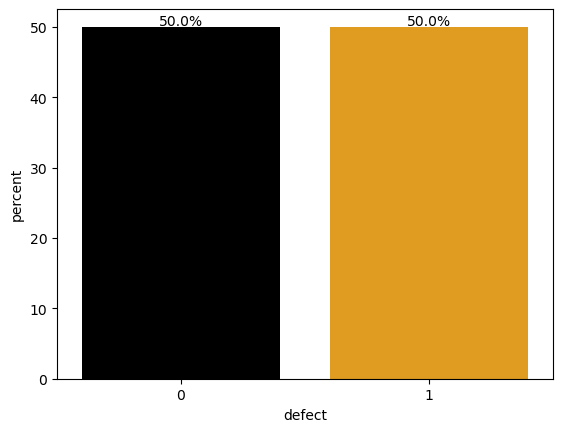

In [56]:
norm_target = (dataset
               .defect
               .value_counts(normalize=True)
               .mul(100)
               .rename('percent')
               .reset_index())
ax = sns.barplot(x='defect', y='percent', data=norm_target, palette=['black', 'orange'], hue='defect', legend=False)
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}%',
        (p.get_x() + p.get_width()/2.0, p.get_height()),
        ha='center',
        va='center',
        xytext=(0,4),
        textcoords='offset points'
    )

Посмотрим распределения признаков для ПО с наличием и отсутствием дефектов по отдельности

In [57]:
import matplotlib.pyplot as plt

In [78]:
def draw_kde_feature_defects(feature, xlim=None):
    sns.displot(
        {
            'defect 0': dataset[dataset.defect==0][feature],
            'defect 1': dataset[dataset.defect==1][feature]
        },
        kind='kde',
        common_norm=True,
        palette=['black', 'orange']
    )
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('density')
    if xlim:
        plt.xlim(-50, xlim) 
    plt.show()

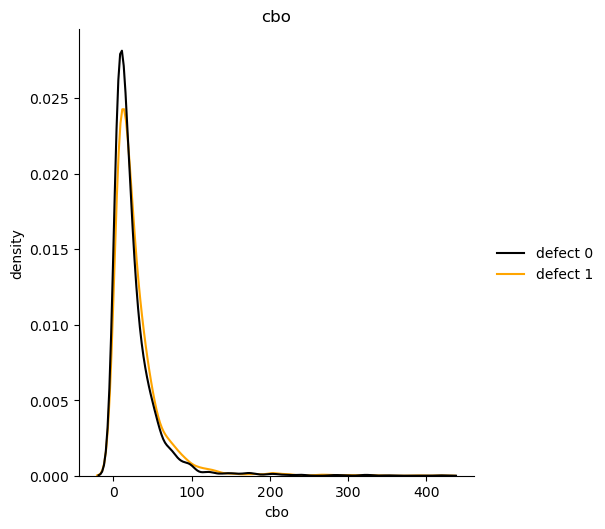

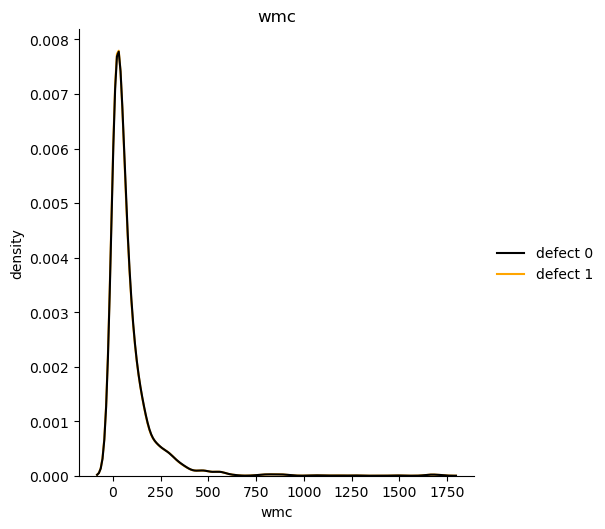

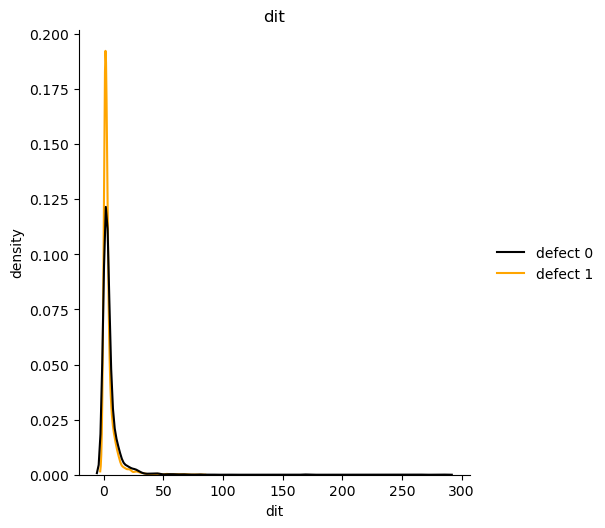

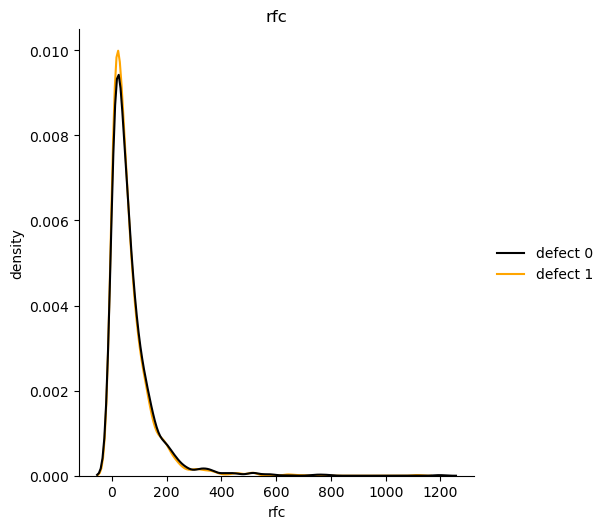

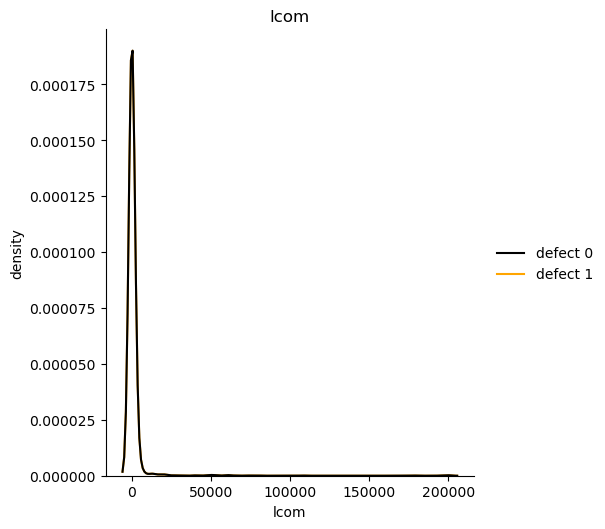

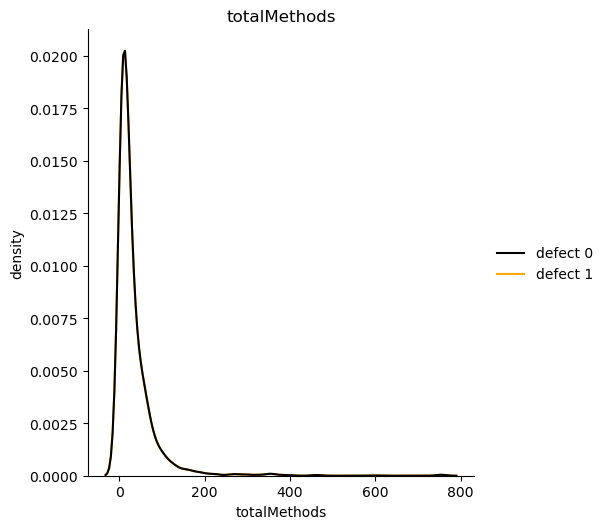

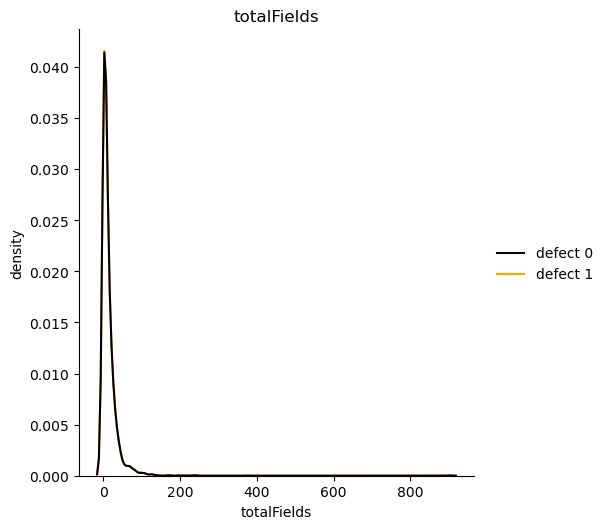

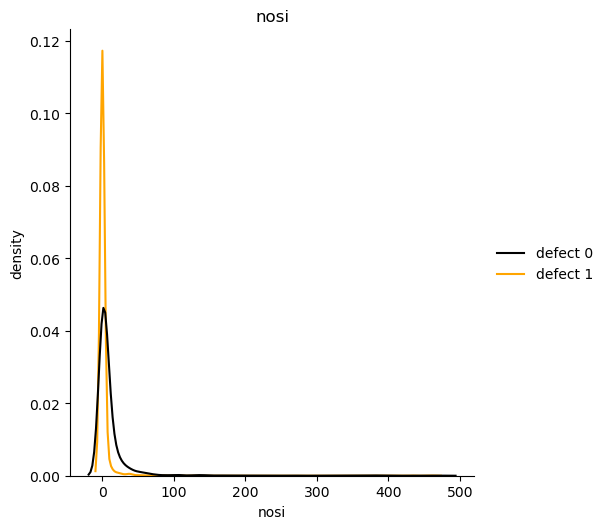

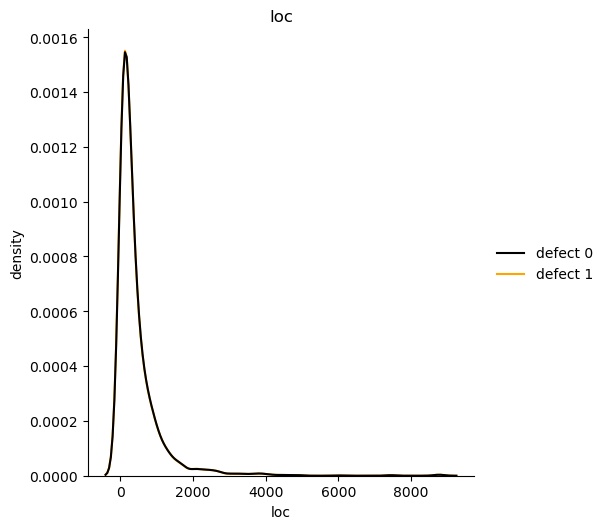

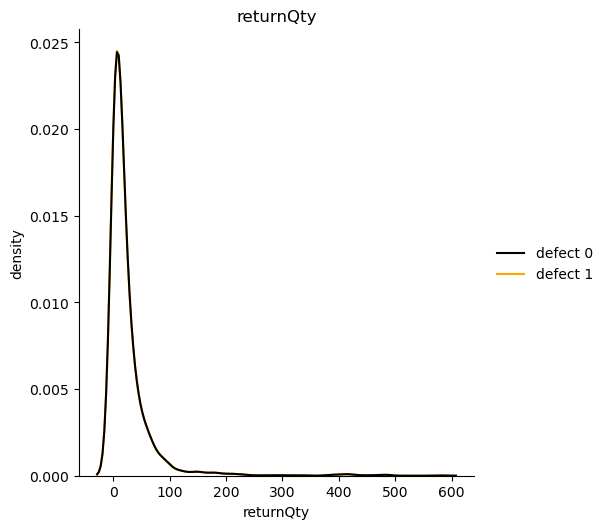

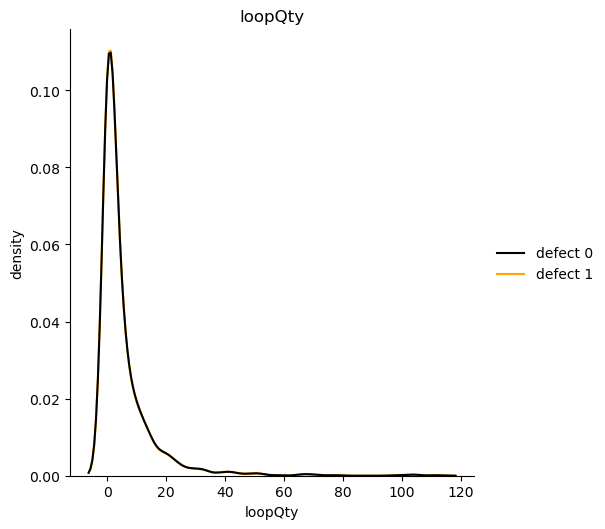

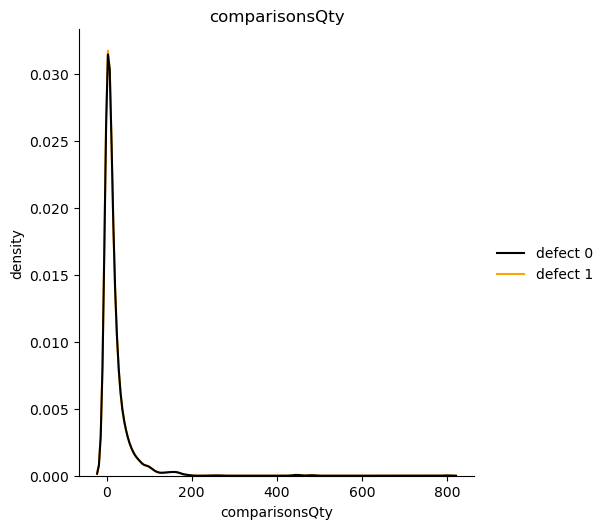

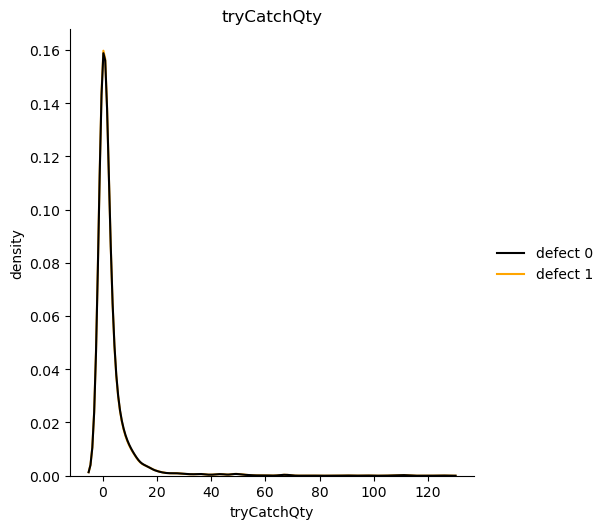

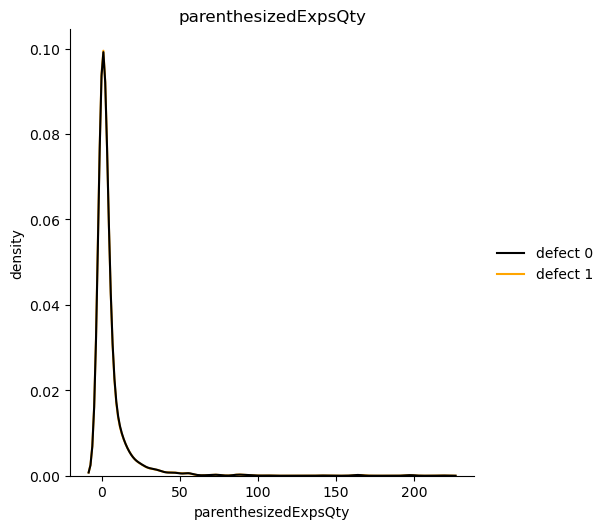

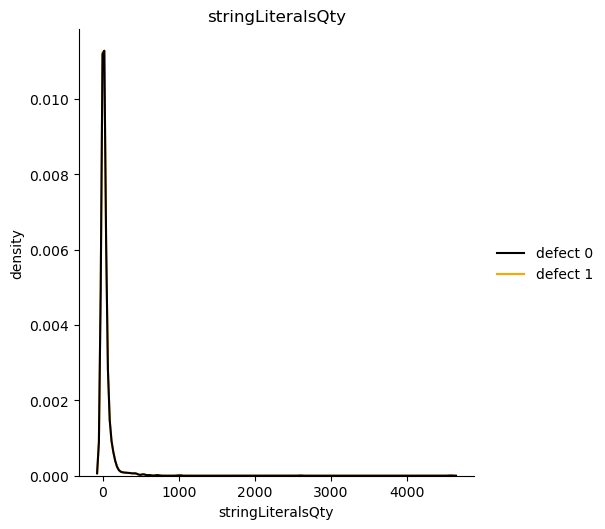

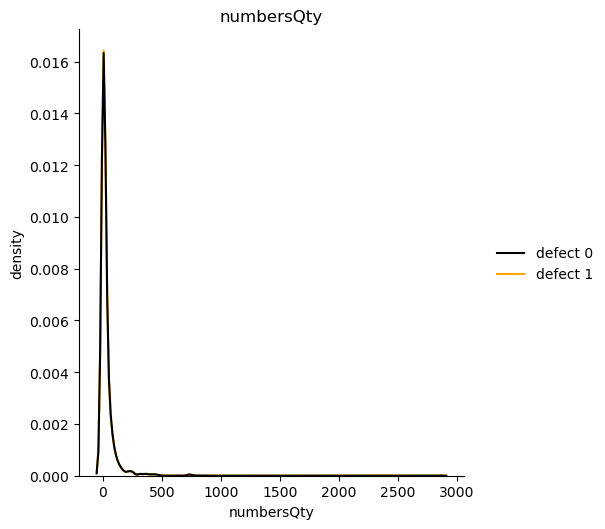

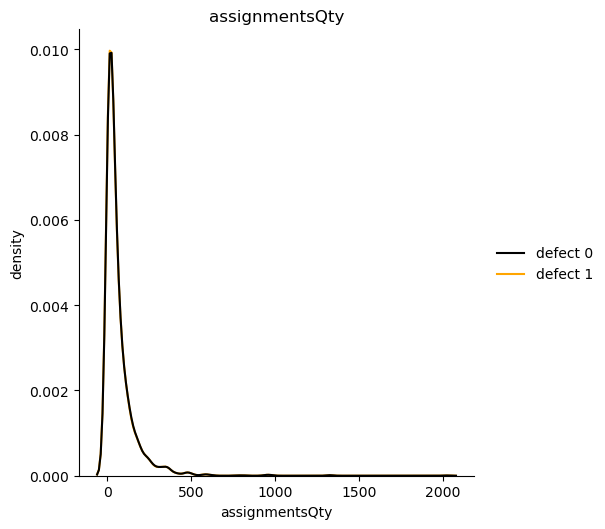

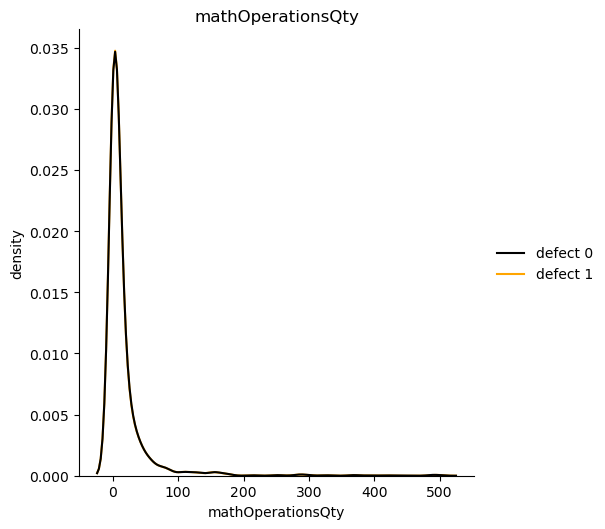

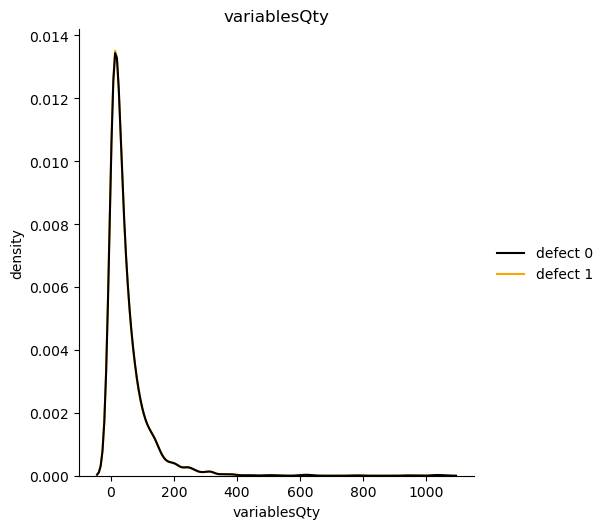

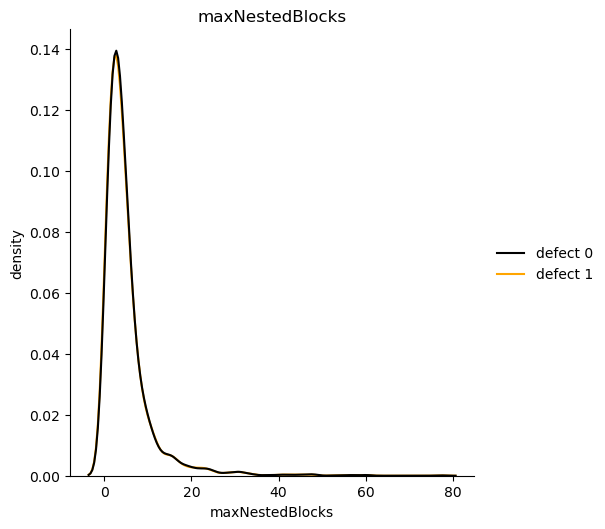

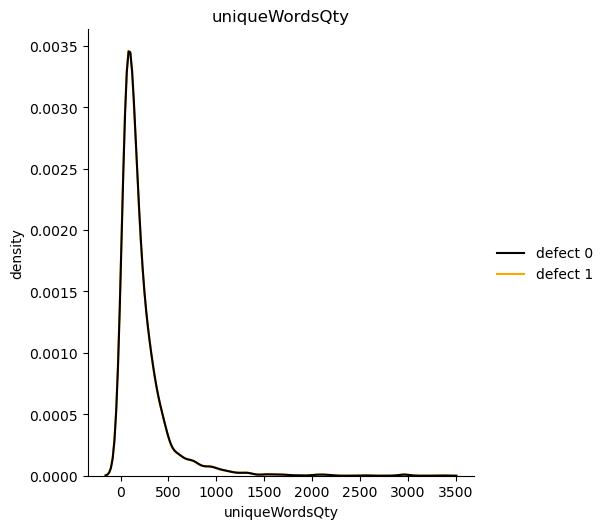

In [72]:
for feature in dataset.columns.values[:-1]:
    draw_kde_feature_defects(feature)

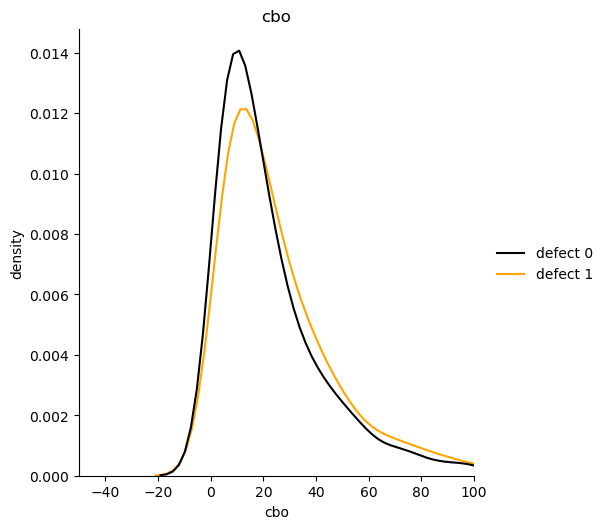

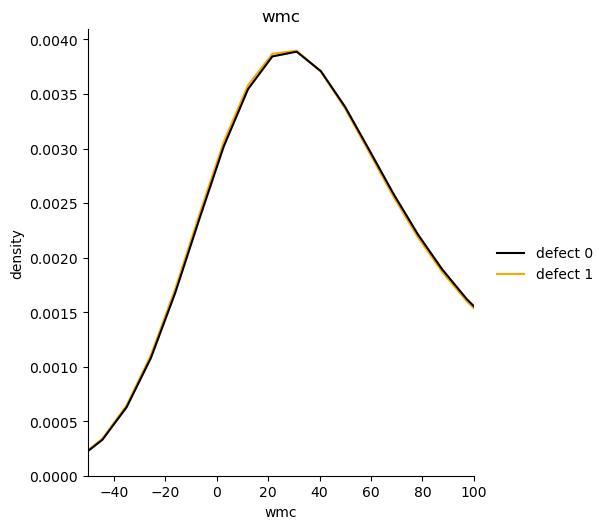

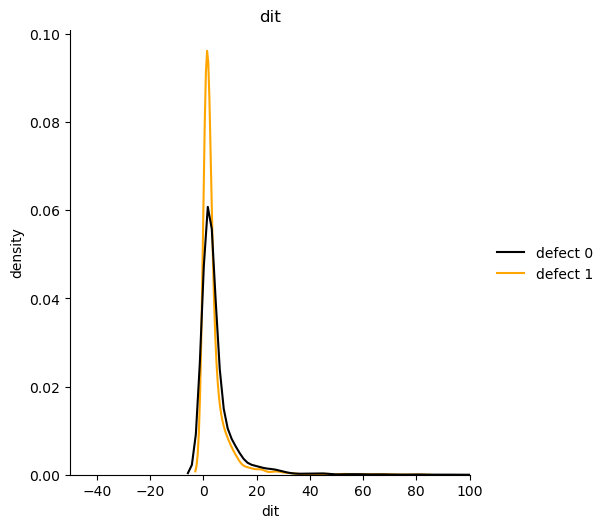

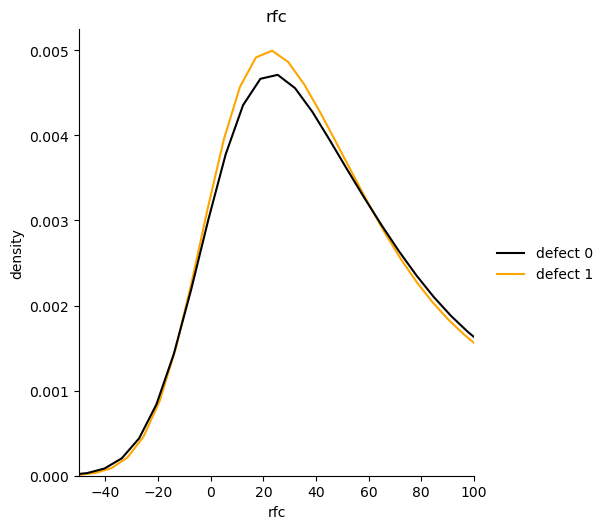

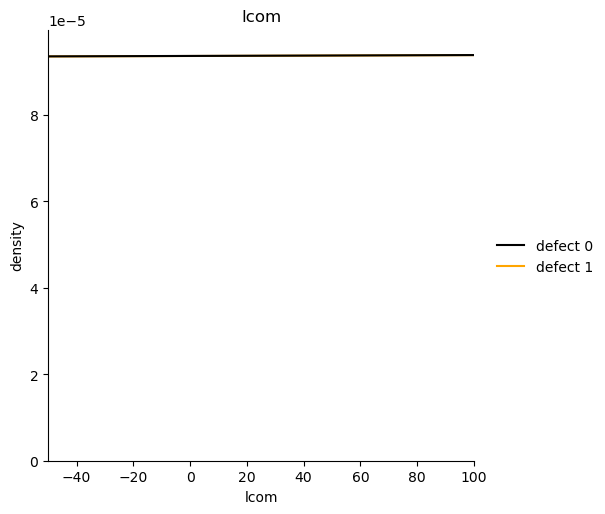

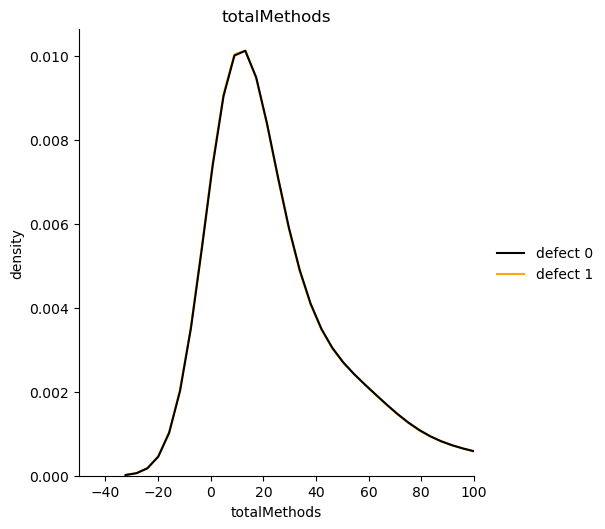

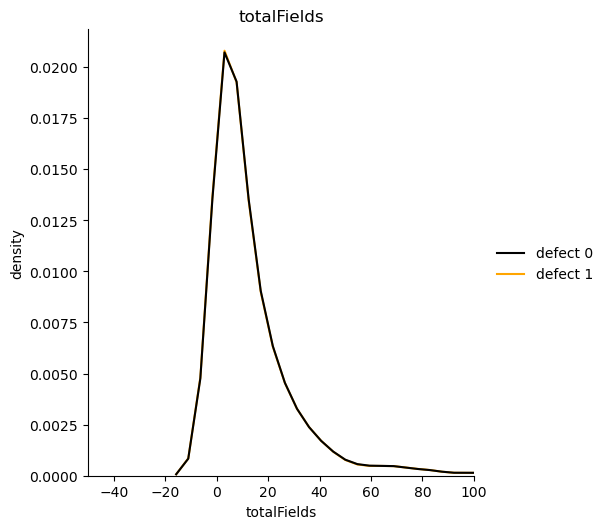

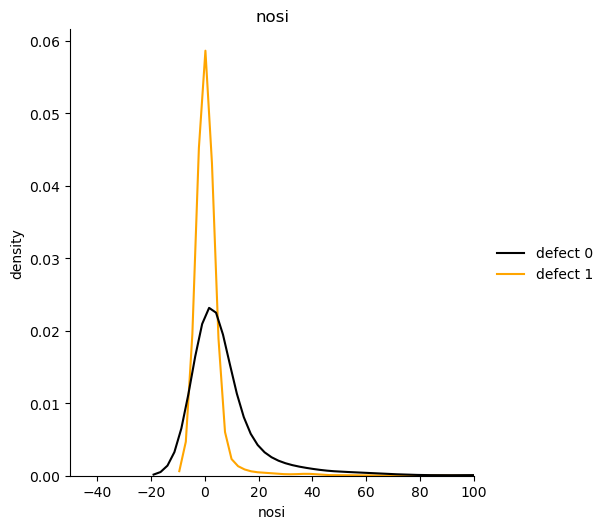

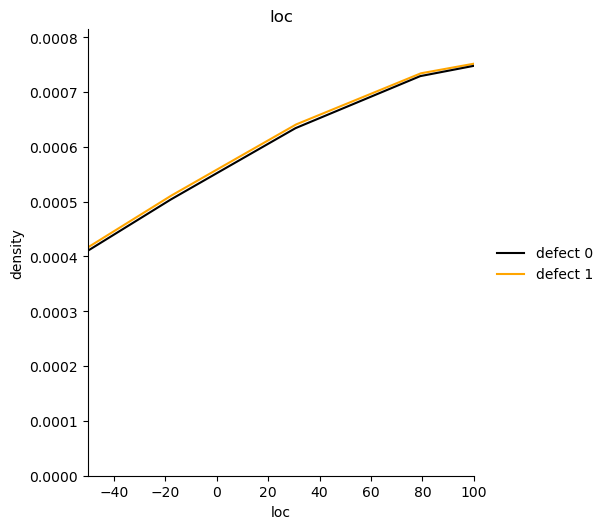

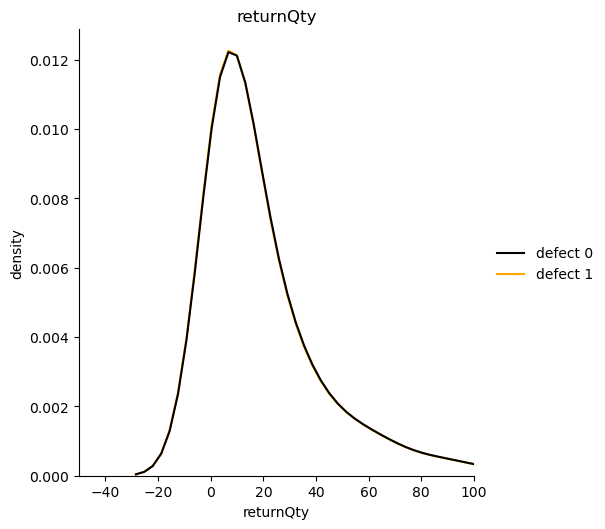

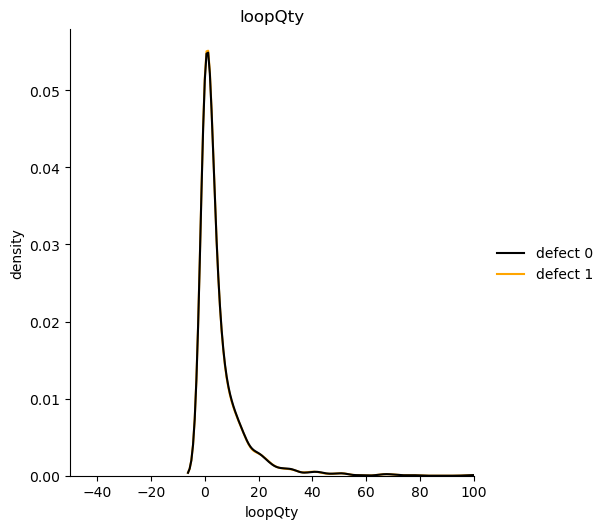

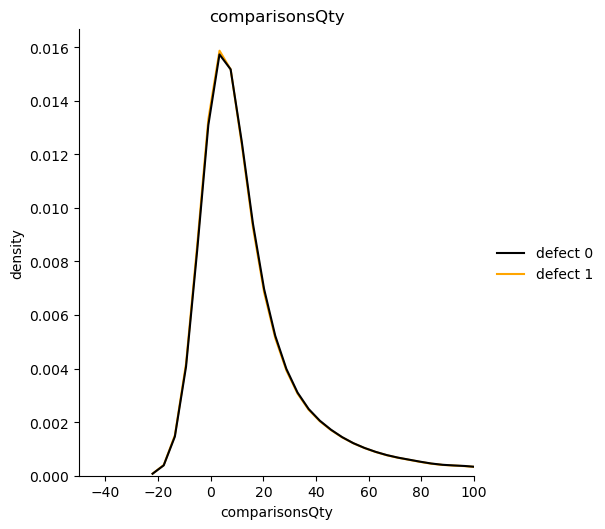

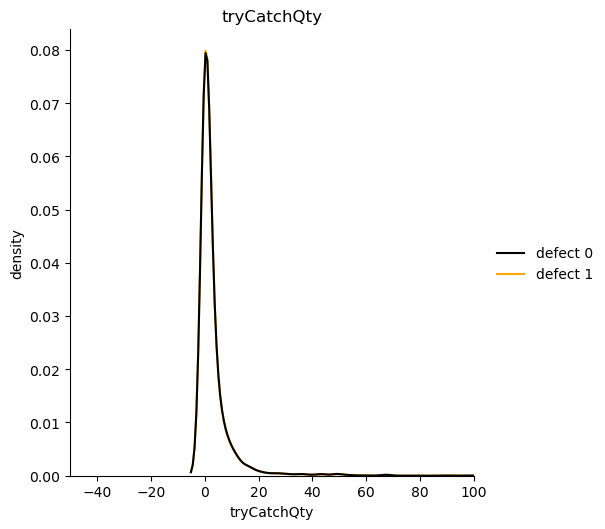

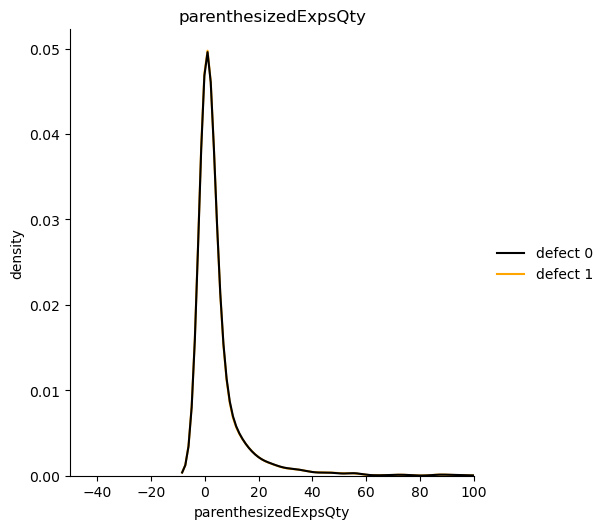

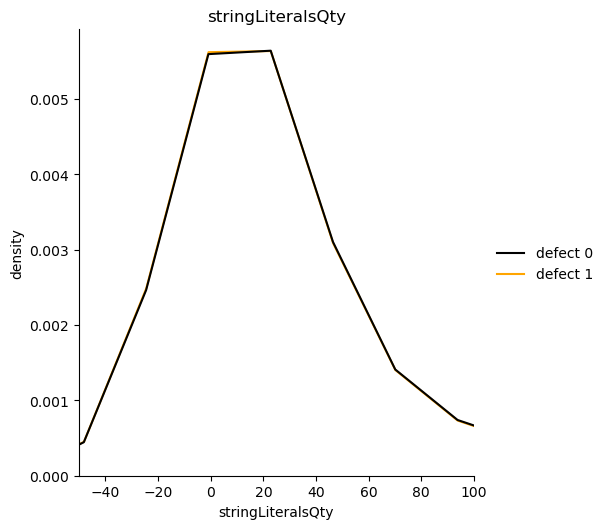

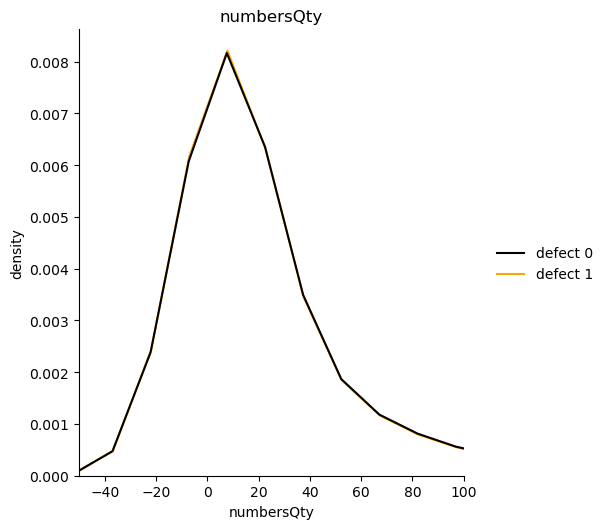

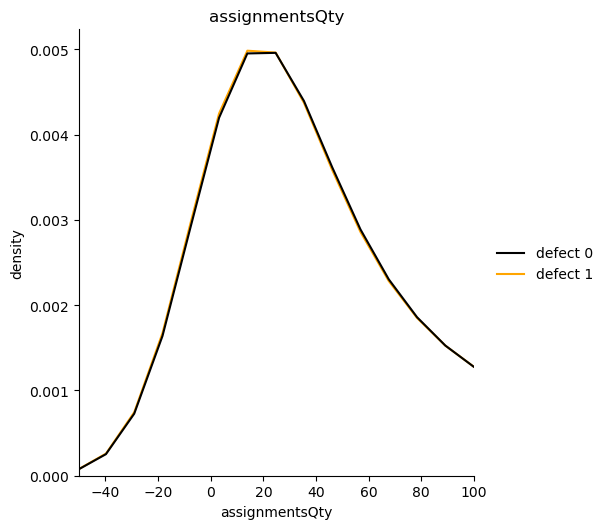

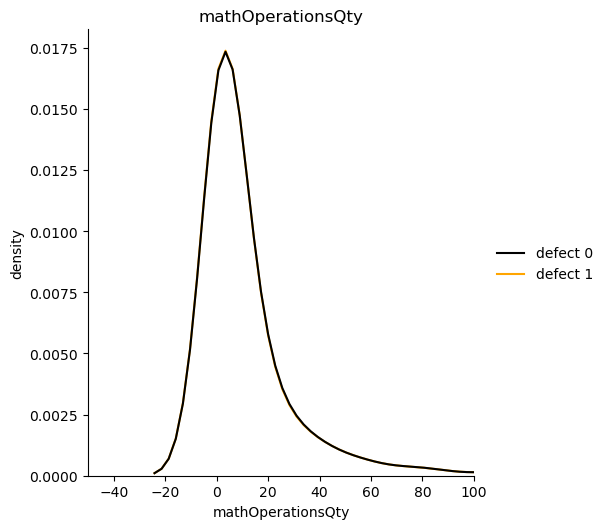

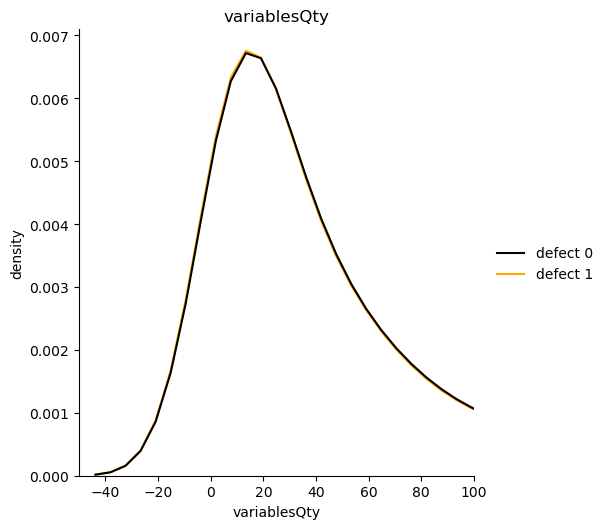

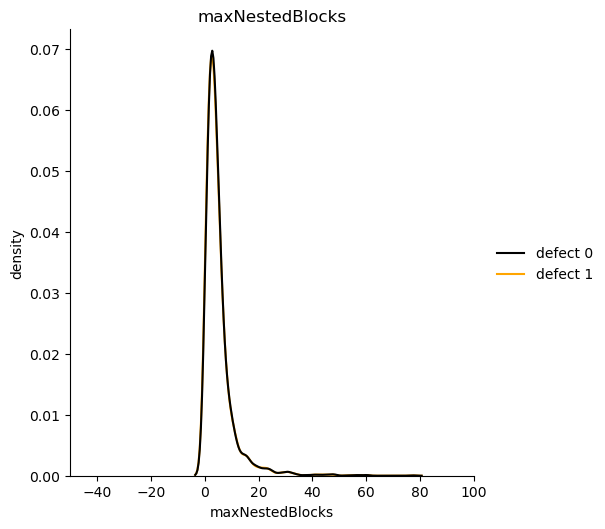

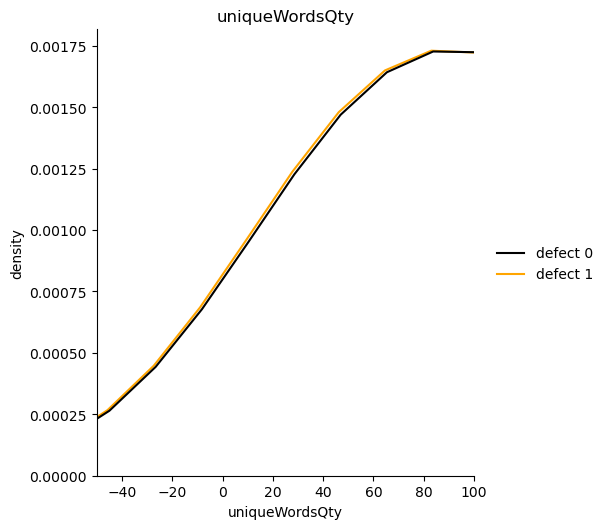

In [79]:
for feature in dataset.columns.values[:-1]:
    draw_kde_feature_defects(feature, 100)

Хоть сколько-то значимую информацию, возможно, несут только 4 признака: nosi, cbo, dit, rfc. Посмотрим их статистику

In [115]:
def describe_feture_defects(feature, ds = dataset):
    print(feature)
    print(ds.groupby('defect')[feature].describe())
    print('\n')

In [61]:
for feature in ['nosi', 'cbo', 'dit', 'rfc']:
    describe_feture_defects(feature)

nosi
         count       mean        std  min  25%  50%  75%    max
defect                                                         
0       3026.0  10.165565  31.529842  0.0  0.0  2.0  8.0  475.0
1       3026.0   1.724719  15.712686  0.0  0.0  0.0  0.0  464.0


cbo
         count       mean        std  min   25%   50%   75%    max
defect                                                            
0       3026.0  25.375083  31.549092  0.0   8.0  16.0  32.0  419.0
1       3026.0  29.612360  34.676919  0.0  10.0  20.0  37.0  416.0


dit
         count      mean        std  min  25%  50%  75%    max
defect                                                        
0       3026.0  5.218440  11.282790  1.0  1.0  2.0  5.0  285.0
1       3026.0  3.979841   6.671607  1.0  1.0  2.0  4.0   81.0


rfc
         count      mean        std  min   25%   50%    75%     max
defect                                                             
0       3026.0  70.96497  88.686176  0.0  18.0  45.0  92.00  1203

In [68]:
def mode_feature_defects(feature):
    print(dataset.groupby('defect')[feature].apply(lambda x: x.value_counts().index[0]))
    print('\n')

In [69]:
for feature in ['nosi', 'cbo', 'dit', 'rfc']:
    mode_feature_defects(feature)

defect
0    0
1    0
Name: nosi, dtype: int64


defect
0    9
1    9
Name: cbo, dtype: int64


defect
0    1
1    1
Name: dit, dtype: int64


defect
0    0
1    0
Name: rfc, dtype: int64




## Замечания
Вспомним:
| Признак | Описание |
|---------|----------|
| `nosi` | Number of Static Invocations (вызовы статических методов) |
| `cbo` | Coupling Between Objects (связи между классами) |
| `dit` | Depth of Inheritance Tree (глубина наследования) |
| `rfc` | Response for a Class (количество вызываемых методов) |

Получается:
1. Чем больше cbo, тем выше вероятность к дефекту
2. Характеристики dit говорят о том, что среднее дефектного ПО ниже, однако 50й процентиль одинаков, поэтому сложно что-то сказать о характерных отличиях экземляров, принадлежащих классам
3. Чем ниже rfc, тем выше вероятность к дефекту. Возможно, это связано с тем, что при малом количестве вызываемых методов происходит усложнение кода и алгоритмов в частости
4. Признак nosi самый интересный для данной задачи, ведь показывает явные маркеры принадлежности к тому или иному классу. То есть в среднем nosi выше у бездефектного ПО. Кроме того, 75й процентиль у дефектного ПО равен 0, поэтому не исключаю возможность бинаризировать nosi

<Axes: >

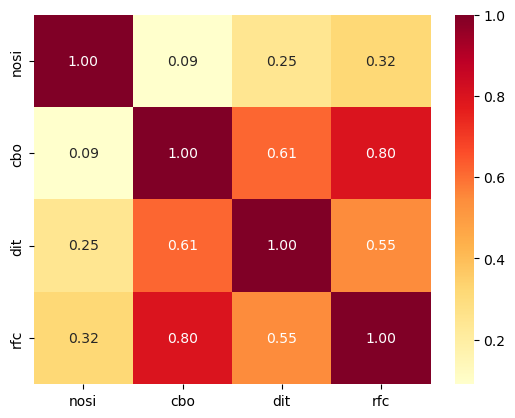

In [99]:
sns.heatmap(data=dataset[['nosi', 'cbo', 'dit', 'rfc']].corr(method='spearman'), fmt='.2f', annot=True, cmap='YlOrRd')

Видно, что cbo,dit и rfc коррелируют между собой, поэтому, например, для логистической регрессии можно объединить эти признаки в одну компоненту.

# Baseline

In [140]:
from sklearn.model_selection import train_test_split

X, y = dataset.drop('defect', axis=1), dataset['defect']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [142]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, log_loss

In [141]:
rfc = RandomForestClassifier(n_estimators=150)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [150]:
y_pred_rfc = rfc.predict(X_test)
y_pred_proba_rfc = rfc.predict_proba(X_test)
print(
    f'''ROC_AUC: {roc_auc_score(y_test, y_pred_proba_rfc[:, 1]):.3f}
Precision: {precision_score(y_test, y_pred_rfc):.3f}
Recall: {recall_score(y_test, y_pred_rfc):.3f}
F1: {f1_score(y_test, y_pred_rfc):.3f}
Logloss: {log_loss(y_test, y_pred_rfc):.3f}
''')

ROC_AUC: 0.741
Precision: 0.696
Recall: 0.728
F1: 0.711
Logloss: 10.579



In [152]:
metrics = pd.DataFrame(index=['roc-auc', 'precision', 'recall', 'f1', 'logloss'])
metrics['Baseline_RFC'] = [
    roc_auc_score(y_test, y_pred_proba_rfc[:, 1]),
    precision_score(y_test, y_pred_rfc),
    recall_score(y_test, y_pred_rfc),
    f1_score(y_test, y_pred_rfc),
    log_loss(y_test, y_pred_rfc)
]
metrics

,Baseline_RFC
roc-auc,0.740521
precision,0.695975
recall,0.727575
f1,0.711424
logloss,10.578892


In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.fit_transform(X_test)
X_train_std.shape

(4236, 21)

In [8]:
from sklearn.decomposition import PCA 
pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
X_train_pca.shape

(4236, 21)

In [9]:
pca.explained_variance_ratio_

array([0.54489288, 0.09884043, 0.05769017, 0.05420303, 0.04495576,
       0.03474345, 0.02804705, 0.02687205, 0.023041  , 0.01626764,
       0.0141156 , 0.01257704, 0.010637  , 0.00888181, 0.00719938,
       0.00561606, 0.00458228, 0.00309765, 0.00210859, 0.00096158,
       0.00066955])

In [14]:
from sklearn.manifold import TSNE
tsne = TSNE(init='random')
X_train_tsne = tsne.fit_transform(X_train_std)
X_train_tsne.shape

(4236, 2)

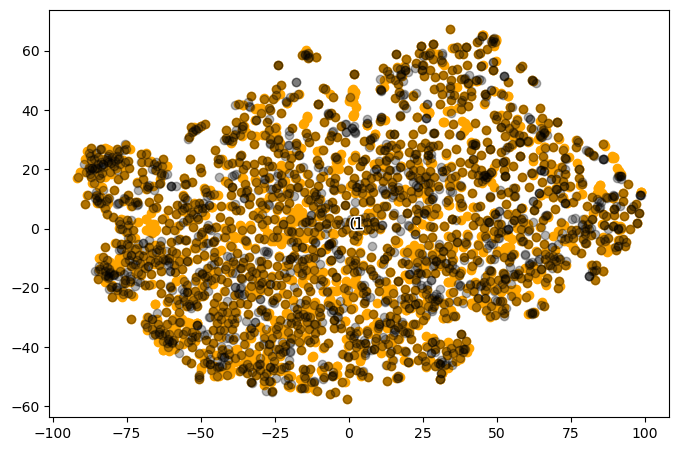

In [15]:
import matplotlib.patheffects as PathEffects

plt.figure(figsize=(8,8))
ax = plt.subplot(aspect='equal')
plt.scatter(
    X_train_tsne[y_train==0, 0], 
    X_train_tsne[y_train==0, 1], 
    color='orange'
)
xtext, ytext = np.median(X_train_tsne[y_train==0, :], axis=0)
txt = ax.text(xtext, ytext, str(0), fontsize=12)
txt.set_path_effects([
    PathEffects.Stroke(linewidth=2, foreground='white'),
    PathEffects.Normal()
])
plt.scatter(
    X_train_tsne[y_train==1, 0], 
    X_train_tsne[y_train==1, 1], 
    color='black',
    alpha=0.3
)
xtext, ytext = np.median(X_train_tsne[y_train==1, :], axis=0)
txt = ax.text(xtext, ytext, str(1), fontsize=12)
txt.set_path_effects([
    PathEffects.Stroke(linewidth=2, foreground='white'),
    PathEffects.Normal()
])
plt.show()

In [48]:
from sklearn.linear_model import LogisticRegressionCV

lrcv = LogisticRegressionCV(cv=5)
lrcv.fit(X_train_sorted_importances[:, :2], y_train)

C:\Anaconda\envs\mltypical\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Anaconda\envs\mltypical\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass set

In [51]:
X_test_sorted = X_test_std[:, sorted_idx]

y_pred_lrcv = lrcv.predict(X_test_sorted[:, :2])
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_lrcv):.3f}')

ROC-AUC: 0.690


In [54]:
lrcv_std = LogisticRegressionCV(cv=5)
lrcv_std.fit(X_train_std, y_train)
y_pred_lrcv_std = lrcv_std.predict(X_test)
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_lrcv_std):.3f}')

ROC-AUC: 0.524


C:\Anaconda\envs\mltypical\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Anaconda\envs\mltypical\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
